# Group 2 · Lab A — Healing the Broken Network (Training Fixes)

**What this lab proves:** In Group 1 we built a deep network and *watched its gradients vanish*.
Now we fix it — one tool at a time — and **measure each fix working.**

We apply the fixes in order, re-measuring the per-layer gradient norms after each:

1. **ReLU activation** (Card 1) — replace the saturating sigmoid
2. **He initialization** (Card 2) — start the weights in a healthy scale
3. **Batch normalization** (Card 3) — keep activations healthy during training
4. **Optimizers** (Card 4) — SGD vs Momentum vs Adam, compared on training speed

The deliverable is the same gradient-norm plot from Group 1, redrawn after each fix — you'll watch
the vanishing-gradient staircase **flatten out**. This is the payoff of exposing the problem first.

*All PyTorch, so every fix is something you set explicitly and can see the effect of.*

## 0 · Colab setup (light)

Group 2 Lab A trains small networks on synthetic data — seconds per run. Same light precautions as
Group 1: set a **GPU runtime** (*Runtime → Change runtime type → T4*) and mount Drive to save the
final plots.

In [2]:
# Mount Google Drive to save output plots (safe to skip if not on Colab).
SAVE_DIR = "."
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive"
    print("Drive mounted. Plots will save to:", SAVE_DIR)
except Exception as e:
    print("Not on Colab (or skipped). Saving locally. Reason:", type(e).__name__)

Mounted at /content/drive
Drive mounted. Plots will save to: /content/drive/MyDrive


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Fix seeds so your run matches the explanation (reproducibility).
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 1 · The task — a spiral (needs a deep, non-linear network)

We use a **two-class spiral** dataset. It's deliberately chosen because the two classes are twisted
together — a shallow or linear model *cannot* separate them, so we genuinely need a deep network.
That makes it the perfect testbed: if our network can't train properly, it will fail visibly here.

No download needed — we generate it mathematically.

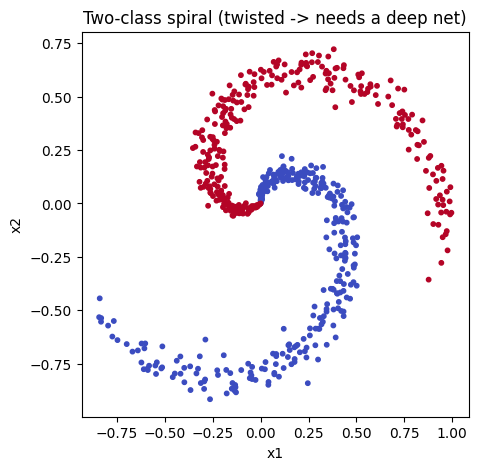

Data shape: torch.Size([600, 2])  Labels: torch.Size([600])


In [4]:
# Generate a two-class spiral. Each class is a spiral arm; the two arms interleave,
# so the decision boundary is highly non-linear -> a real test for a deep network.
def make_spiral(points_per_class=300, n_classes=2, noise=0.2):
    X, y = [], []
    for c in range(n_classes):
        r = np.linspace(0.0, 1.0, points_per_class)                 # radius: 0 -> 1
        # angle sweeps a different range per class, so each class is its own arm.
        t = np.linspace(c * 4, (c + 1) * 4, points_per_class) + np.random.randn(points_per_class) * noise
        X.append(np.c_[r * np.sin(t), r * np.cos(t)])               # (x, y) points on the arm
        y += [c] * points_per_class                                 # label = class index
    X = np.concatenate(X).astype(np.float32)
    y = np.array(y).astype(np.int64)
    return torch.from_numpy(X), torch.from_numpy(y)

X, y = make_spiral()
X, y = X.to(device), y.to(device)

# Visualize it so you can see why it's hard.
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), cmap="coolwarm", s=10)
plt.title("Two-class spiral (twisted -> needs a deep net)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

print("Data shape:", X.shape, " Labels:", y.shape)

## 2 · One configurable network, so we can toggle each fix

Rather than write four separate networks, we build **one** flexible `DeepMLP` with switches:
- `activation` — `"sigmoid"` (the broken baseline) or `"relu"` (the fix)
- `use_bn` — insert BatchNorm after each linear layer, on/off
- `init` — `"default"` or `"he"` (He/Kaiming initialization)

This lets us change **one thing at a time** and measure its effect — the essence of a controlled
experiment. The network is 6 layers deep so the vanishing gradient has room to appear.

In [5]:
class DeepMLP(nn.Module):
    def __init__(self, depth=6, width=32, activation="sigmoid", use_bn=False, init="default"):
        super().__init__()

        # Pick the activation class from a lookup table based on the string argument.
        acts = {"sigmoid": nn.Sigmoid, "relu": nn.ReLU}
        Act = acts[activation]

        layers = []
        in_f = 2                       # input is 2D (x1, x2)
        for i in range(depth):
            layers.append(nn.Linear(in_f, width))   # linear layer
            if use_bn:
                # BatchNorm1d normalizes the `width` features of this layer (Card 3).
                # Placed BEFORE the activation is a common, effective choice.
                layers.append(nn.BatchNorm1d(width))
            layers.append(Act())        # activation (sigmoid or relu)
            in_f = width                # next layer's input size = this layer's width
        layers.append(nn.Linear(in_f, 2))   # output layer: 2 class scores

        # nn.Sequential chains everything; forward() just runs the chain.
        self.net = nn.Sequential(*layers)

        # He / Kaiming initialization (Card 2). Only applied when init="he".
        # It sets each linear layer's weights to a variance matched to ReLU,
        # so the signal neither explodes nor vanishes at the start.
        if init == "he":
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

### A helper to measure gradient health

This function does one forward + backward pass and returns the **gradient norm of every linear
layer** — the same measurement from Group 1 Lab A. It's how we'll *quantify* whether each fix is
working: healthy training means the first-layer gradient isn't tiny compared to the last.

In [6]:
def layer_grad_norms(model, X, y):
    """One forward+backward pass; return the gradient norm of each Linear layer (input -> output)."""
    criterion = nn.CrossEntropyLoss()
    model.zero_grad()                       # clear any old gradients
    loss = criterion(model(X), y)           # forward + loss
    loss.backward()                         # backprop -> fills .grad on every parameter
    # Collect the L2 norm of each linear layer's weight gradient, in order.
    return [m.weight.grad.norm().item() for m in model.modules() if isinstance(m, nn.Linear)]

## 3 · Apply the fixes one at a time, measuring gradient health

Now the core experiment. We build four versions of the network — each adding one more fix — and
record the per-layer gradient norms for each. Watch the **ratio of last-layer to first-layer
gradient**: the bigger it is, the worse the vanishing gradient. A healthy network drives this ratio
toward ~1 (all layers learning equally).

In [7]:
# Each config adds ONE more fix than the previous, so we isolate each fix's effect.
configs = [
    ("sigmoid (baseline)", dict(activation="sigmoid", use_bn=False, init="default")),
    ("ReLU",               dict(activation="relu",    use_bn=False, init="default")),
    ("ReLU + He init",     dict(activation="relu",    use_bn=False, init="he")),
    ("ReLU + He + BN",     dict(activation="relu",    use_bn=True,  init="he")),
]

results = {}   # store each config's per-layer gradient norms for plotting
print("Per-layer gradient norms (first layer -> last layer):\n")
for name, cfg in configs:
    torch.manual_seed(0)                       # same seed each time -> fair comparison
    model = DeepMLP(depth=6, width=32, **cfg).to(device)
    model.train()                              # train mode (matters for BatchNorm)
    norms = layer_grad_norms(model, X, y)
    results[name] = norms
    ratio = norms[-1] / (norms[0] + 1e-12)     # last/first: how lopsided is the learning?
    print(f"  {name:22s}: first={norms[0]:.6f}  last={norms[-1]:.6f}  ratio={ratio:,.1f}x")

Per-layer gradient norms (first layer -> last layer):

  sigmoid (baseline)    : first=0.000001  last=0.181959  ratio=198,534.7x
  ReLU                  : first=0.000632  last=0.007868  ratio=12.5x
  ReLU + He init        : first=0.050041  last=0.504822  ratio=10.1x
  ReLU + He + BN        : first=0.837579  last=0.682589  ratio=0.8x


##What you'll see:
 the sigmoid baseline has a last/first ratio in the hundreds of thousands (the first layer is essentially dead). ReLU cuts it to ~12×. Adding He init brings the first-layer gradient up by orders of magnitude. Adding BatchNorm drives the ratio to ~1 — every layer learning equally. The vanishing gradient is healed.

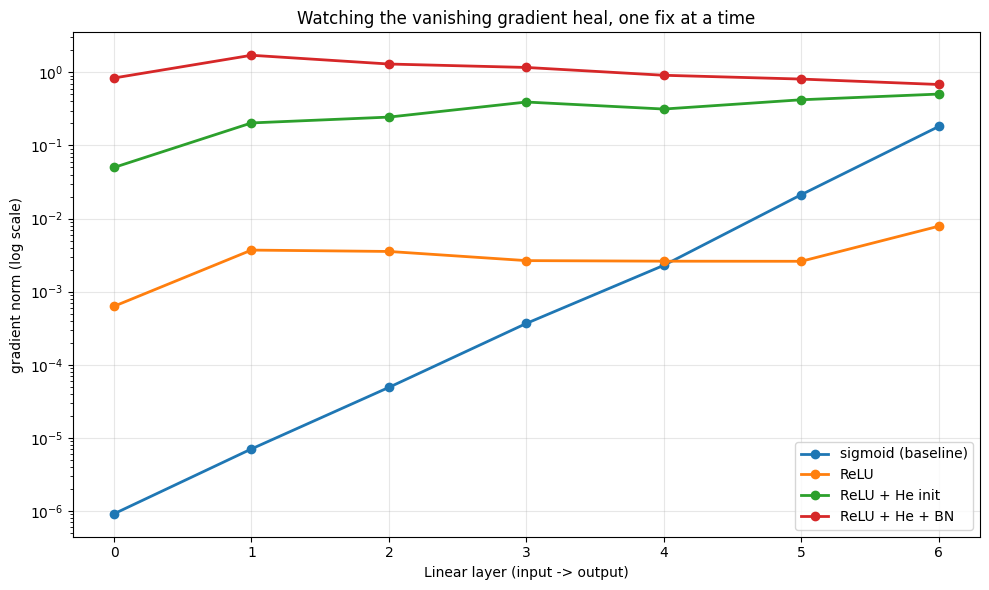

In [8]:
# Plot all four configs on one log-scale chart: gradient norm vs layer depth.
plt.figure(figsize=(10, 6))
for name, norms in results.items():
    plt.plot(range(len(norms)), norms, "o-", label=name, linewidth=2)

plt.yscale("log")                      # log scale: the norms span many orders of magnitude
plt.xlabel("Linear layer (input -> output)")
plt.ylabel("gradient norm (log scale)")
plt.title("Watching the vanishing gradient heal, one fix at a time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/g2_lab_a_gradient_healing.png", dpi=120)
plt.show()

##Reading the plot:
 the sigmoid line dives steeply toward the input layer (vanishing). Each fix lifts and flattens the line. The ReLU+He+BN line is nearly horizontal — the signature of a healthy deep network where gradients reach every layer.

## 4 · Optimizers — the update rule matters too (Card 4)

The fixes above keep the *gradient signal* healthy. But the **optimizer** — the rule that turns
gradients into weight updates — decides how fast and stably the network actually converges. We take
the fully-fixed network (ReLU + He + BN) and train it three ways, comparing loss curves:

- **SGD** — the plain baseline (Group 1's manual update, automated)
- **SGD + momentum** — accumulates velocity, powers through flat regions
- **Adam** — momentum + per-parameter adaptive learning rates (the default)

In [9]:
def train(model, optimizer, epochs=300):
    """Train on the spiral; return the loss at every epoch."""
    criterion = nn.CrossEntropyLoss()
    losses = []
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()               # clear grads
        loss = criterion(model(X), y)       # forward + loss
        loss.backward()                     # backprop
        optimizer.step()                    # update weights (the optimizer's job)
        losses.append(loss.item())
    return losses

# Train the SAME architecture with three different optimizers.
curves = {}
for opt_name in ["SGD", "SGD+momentum", "Adam"]:
    torch.manual_seed(0)                    # same start -> fair comparison
    model = DeepMLP(depth=6, width=32, activation="relu", use_bn=True, init="he").to(device)
    if opt_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    elif opt_name == "SGD+momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    curves[opt_name] = train(model, optimizer)
    acc = (model(X).argmax(1) == y).float().mean().item()
    print(f"{opt_name:14s}: final loss {curves[opt_name][-1]:.4f} | train acc {acc:.3f}")

SGD           : final loss 0.0097 | train acc 0.997
SGD+momentum  : final loss 0.0033 | train acc 0.998
Adam          : final loss 0.0028 | train acc 0.998


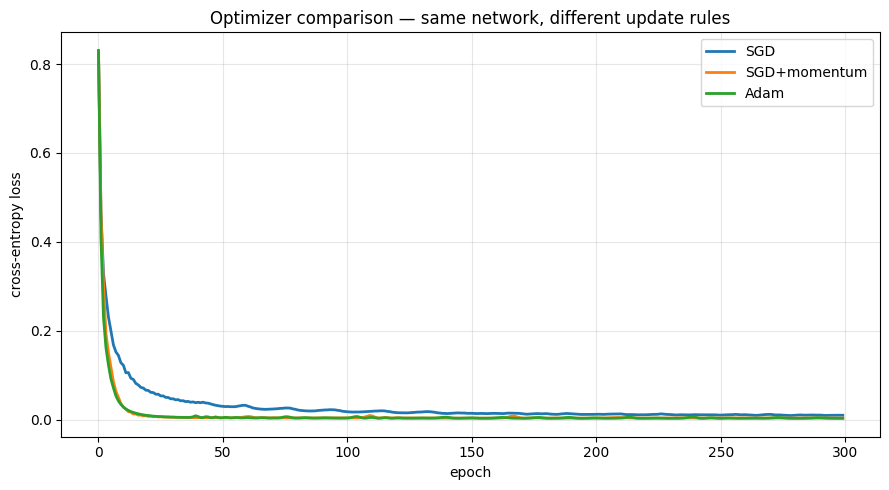

In [10]:
# Compare the three optimizers' loss curves.
plt.figure(figsize=(9, 5))
for opt_name, losses in curves.items():
    plt.plot(losses, label=opt_name, linewidth=2)

plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Optimizer comparison — same network, different update rules")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/g2_lab_a_optimizers.png", dpi=120)
plt.show()

## What you just proved

Starting from the **broken sigmoid network of Group 1**, you healed it by adding one tool at a time
and *measured* each fix:

- **ReLU** cut the gradient imbalance from ~200,000× down to ~12×.
- **He init** lifted the starved first-layer gradient by orders of magnitude.
- **BatchNorm** drove the last/first gradient ratio to ~1 — every layer learning equally.
- **Adam / momentum** converged faster and lower than plain SGD on the healed network.

The vanishing gradient — the problem Group 1 left deliberately unsolved — is now solved, and you
watched each tool do its specific job.

### Still open
The network now trains deep, fast, and stable. But it can still **overfit** (train ≫ test), and it
struggles when data is scarce. That's **Lab B**: dropout, L2 weight decay, data augmentation, and
transfer learning.

### Try it yourself (optional)
- In `configs`, add a `Leaky ReLU` variant — does it help the "dying ReLU" case?
- Set `depth=12` and re-run the gradient plot — the sigmoid baseline gets *even worse*, but the
  ReLU+He+BN line stays flat. Depth stops being scary once the fixes are in place.